**Data Aggregation**

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

eth = pd.read_csv("../data/ethiopia_clean.csv", index_col="Date", parse_dates=True)
ken = pd.read_csv("../data/kenya_clean.csv", index_col="Date", parse_dates=True)
nig = pd.read_csv("../data/nigeria_clean.csv", index_col="Date", parse_dates=True)
sud = pd.read_csv("../data/sudan_clean.csv", index_col="Date", parse_dates=True)
tan = pd.read_csv("../data/tanzania_clean.csv", index_col="Date", parse_dates=True)

all_countries = pd.concat([eth, ken, nig, sud, tan])
all_countries = all_countries.sort_index()

**Departure Analysis**

In [4]:
baseline = all_countries.loc['2015': '2019']
current = all_countries.loc['2020': '2026']

baseline_avg = baseline.groupby('Country')['T2M'].mean()
current_avg = current.groupby('Country')['T2M'].mean()

anomaly = current_avg - baseline_avg
print("Temperature Anomaly (Current vs Baseline):", end=" ")
print(anomaly.sort_values(ascending=False))

Temperature Anomaly (Current vs Baseline): Country
Nigeria     0.211930
Ethiopia    0.093136
Tanzania   -0.025462
Kenya      -0.071655
Sudan      -0.658734
Name: T2M, dtype: float64


**Uncertainty & Distribution**

/tmp/ipykernel_126641/3761598812.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=all_countries, x='Country', y='T2M', palette='Set2')


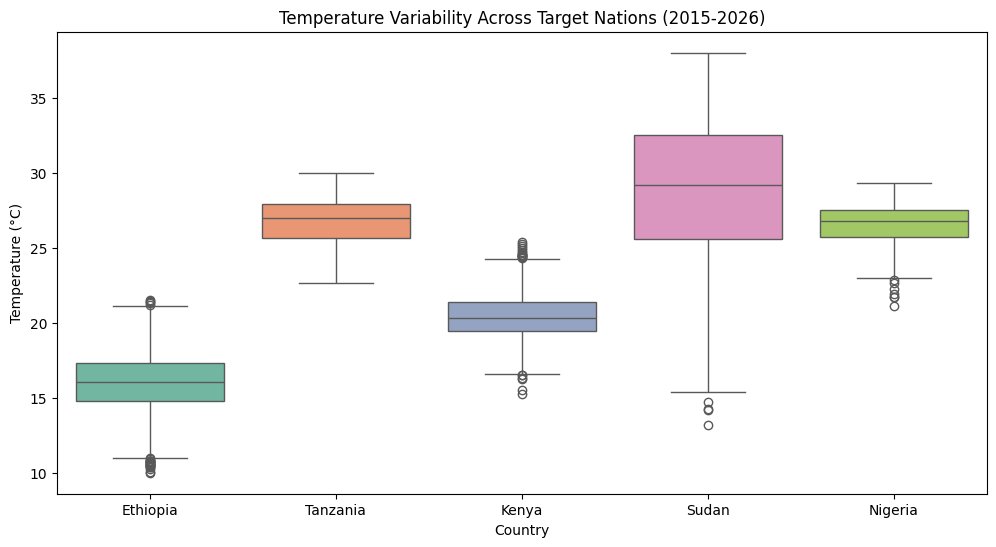

In [5]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=all_countries, x='Country', y='T2M', palette='Set2')
plt.title('Temperature Variability Across Target Nations (2015-2026)')
plt.ylabel('Temperature (°C)')
plt.show()

**Vulnerability Ranking**

In [6]:
precip_volatility = all_countries.groupby('Country')['PRECTOTCORR'].std()

ranking_df = pd.DataFrame({
    'Temp_Anomaly': anomaly,
    'Precip_Volatility': precip_volatility
})

ranking_df['Vulnerability_Score'] = ranking_df['Temp_Anomaly'] + (ranking_df['Precip_Volatility'] / 10)
print(ranking_df.sort_values(by='Vulnerability_Score', ascending=False))

          Temp_Anomaly  Precip_Volatility  Vulnerability_Score
Country                                                       
Nigeria       0.211930           7.266742             0.938604
Tanzania     -0.025462           8.003947             0.774933
Ethiopia      0.093136           6.289061             0.722042
Kenya        -0.071655           3.180228             0.246368
Sudan        -0.658734           3.057672            -0.352966
